# Named Entity Recognition (NER) Pipeline
# Code đầy đủ và data tại: https://github.com/duyhoang17930/Named-Entity-Recognition
## Complete Pipeline: Crawl → Preprocess → label → Encode →  Train → Evaluate → Predict

This notebook contains all steps for building an NER system:
1. **Day1 - Crawl**: Data collection from Google News
2. **Day2 - Preprocess**: Text cleaning and preprocessing
3. **Day3 - Encode**: NER labeling with spaCy
5. **Day4 - Relabeling**: Apply custom entity mappings for improved accuracy
6. **Day5 - Train**: Model training with DistilBERT
7. **Day6 - Results**: Evaluation, visualization, and prediction

# Step 1: Data Crawling (Day1)

Collect news articles from Google News using:
- Chromium browser for page rendering
- Newspaper3k for article extraction
- GoogleNewsDecoder for URL decoding

In [87]:
import sys

!{sys.executable} -m pip install -q pandas newspaper3k googlenewsdecoder DrissionPage nltk spacy lxml_html_clean
!{sys.executable} -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 1.5 MB/s eta 0:00:08
     --- ------------------------------------ 1.0/12.8 MB 1.7 MB/s eta 0:00:07
     ------ --------------------------------- 2.1/12.8 MB 2.4 MB/s eta 0:00:05
     ------ --------------------------------- 2.1/12.8 MB 2.4 MB/s eta 0:00:05
     --------- ------------------------------ 2.9/12.8 MB 2.2 MB/s eta 0:00:05
     ---------- ----------------------------- 3.4/12.8 MB 2.3 MB/s eta 0:00:05
     ------------- -------------------------- 4.2/12.8 MB 2.5 MB/s eta 0:00:04
     --------------- ------------------------ 5.0/12.8 MB 2.6 MB/s eta 0:00:03
     ---


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# CODE FROM Day1_Crawl/crawl.py
import pandas as pd
from newspaper import Article
import nltk
from googlenewsdecoder import new_decoderv1
from DrissionPage import ChromiumPage, ChromiumOptions
import time
import os

## Load Crawled Data

In [5]:
# Load the crawled data (or use existing file)
df = pd.read_csv("Day1_Crawl/ket_qua_sentence.csv")

print("=" * 50)
print("DATA EXPLORATION (Day1)")
print("=" * 50)
print(f"Dataset size: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

DATA EXPLORATION (Day1)
Dataset size: (3680, 2)
Columns: ['Title', 'Sentence']

First 5 rows:


,Title,Sentence
0,US judge halts Trump plan to end protections f...,Summary Companies Lawsuit claims Noem hostil...
1,US judge halts Trump plan to end protections f...,"U.S. District Judge Ana Reyes in Washington, D..."
2,US judge halts Trump plan to end protections f...,The move would have taken effect on Wednesday ...
3,US judge halts Trump plan to end protections f...,The Reuters Inside Track newsletter is your es...
4,US judge halts Trump plan to end protections f...,"Reyes, who was appointed by Democratic former ..."


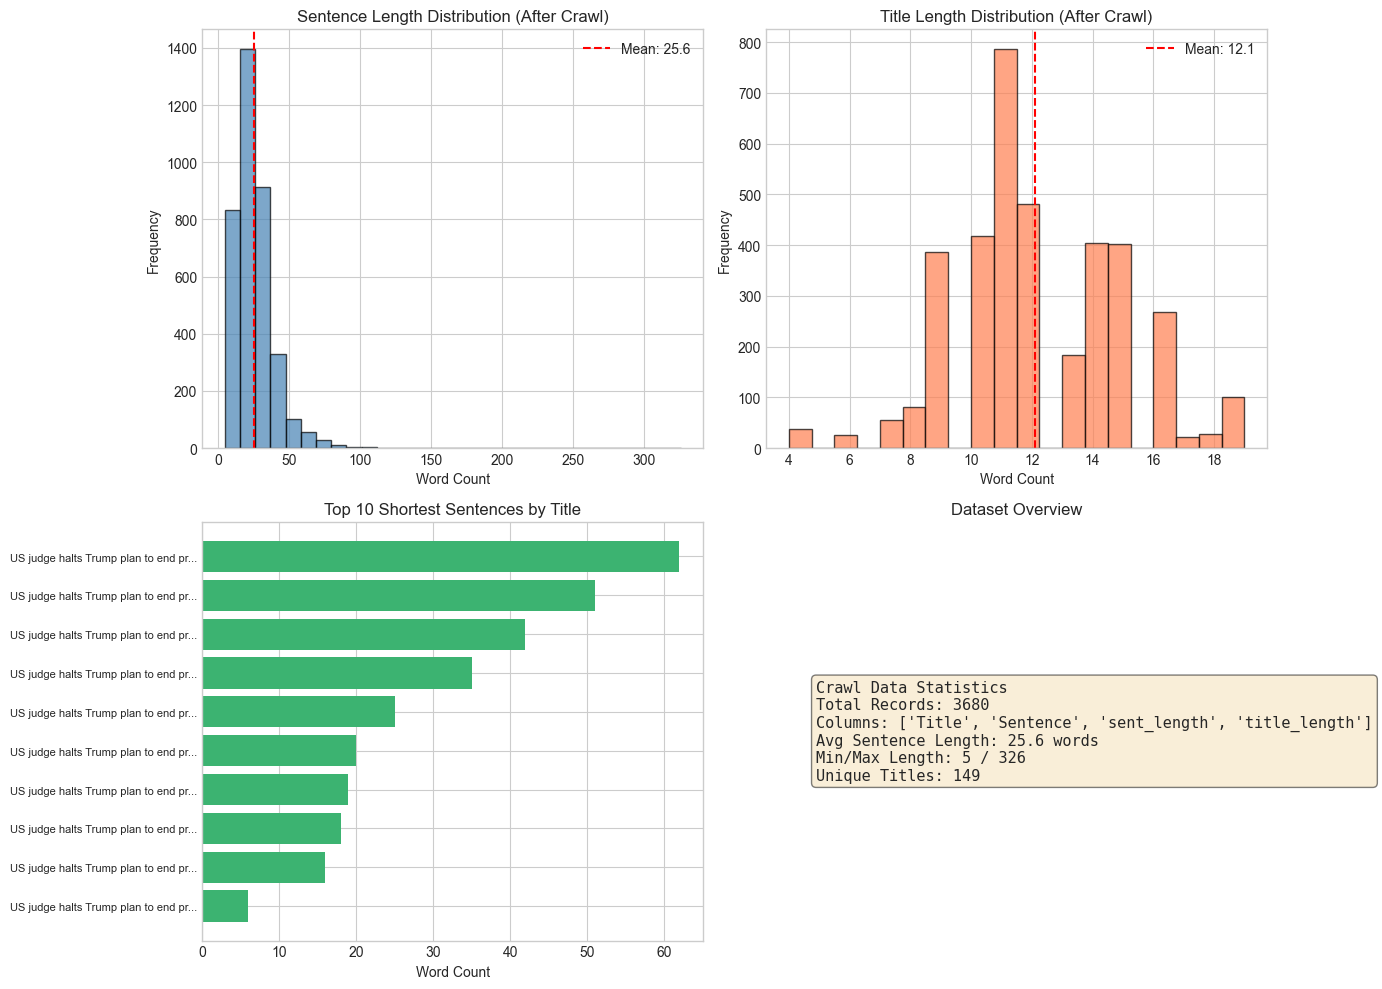

Saved: charts/after_crawl_analysis.png


In [33]:
# Data Visualization: After Crawl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load raw crawl data
df_raw = pd.read_csv('Day1_Crawl/ket_qua_sentence.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentence length distribution
df_raw['sent_length'] = df_raw['Sentence'].apply(lambda x: len(str(x).split()))
axes[0, 0].hist(df_raw['sent_length'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_raw['sent_length'].mean(), color='red', linestyle='--', label='Mean: ' + str(round(df_raw['sent_length'].mean(), 1)))
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Sentence Length Distribution (After Crawl)')
axes[0, 0].legend()

# 2. Title length distribution
df_raw['title_length'] = df_raw['Title'].apply(lambda x: len(str(x).split()))
axes[0, 1].hist(df_raw['title_length'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(df_raw['title_length'].mean(), color='red', linestyle='--', label='Mean: ' + str(round(df_raw['title_length'].mean(), 1)))
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Title Length Distribution (After Crawl)')
axes[0, 1].legend()

# 3. Sample entries
sample_data = df_raw.head(10)[['Title', 'sent_length']].copy().sort_values('sent_length', ascending=True)
axes[1, 0].barh(range(len(sample_data)), sample_data['sent_length'], color='mediumseagreen')
axes[1, 0].set_yticks(range(len(sample_data)))
axes[1, 0].set_yticklabels([t[:35] + '...' if len(t) > 35 else t for t in sample_data['Title']], fontsize=8)
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_title('Top 10 Shortest Sentences by Title')

stats_text = (
    "Crawl Data Statistics\n"
    "Total Records: " + str(len(df_raw)) + "\n"
    "Columns: " + str(df_raw.columns.tolist()) + "\n"
    "Avg Sentence Length: " + str(round(df_raw['sent_length'].mean(), 1)) + " words\n"
    "Min/Max Length: " + str(df_raw['sent_length'].min()) + " / " + str(df_raw['sent_length'].max()) + "\n"
    "Unique Titles: " + str(df_raw['Title'].nunique())
)
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')
axes[1, 1].set_title('Dataset Overview')

plt.tight_layout()
plt.savefig('charts/after_crawl_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/after_crawl_analysis.png')

In [6]:
# More exploration
print(f"Unique titles: {df['Title'].nunique()}")
print(f"Missing values:\n{df.isna().sum()}")
print(f"\nSample sentences:")
for i, sent in enumerate(df['Sentence'].head(3)):
    print(f"{i+1}. {sent[:100]}...")

Unique titles: 149
Missing values:
Title       0
Sentence    0
dtype: int64

Sample sentences:
1. Summary  Companies  Lawsuit claims Noem hostile to nonwhite immigrants  Judge says that claim 'seems...
2. U.S. District Judge Ana Reyes in Washington, D.C., halted, opens new tab the U.S. Department of Home...
3. The move would have taken effect on Wednesday despite spiraling violence there that has displaced mo...


---